Accuracy Train: 0.9
Accuracy Val: 0.88
Accuracy Test: 0.8


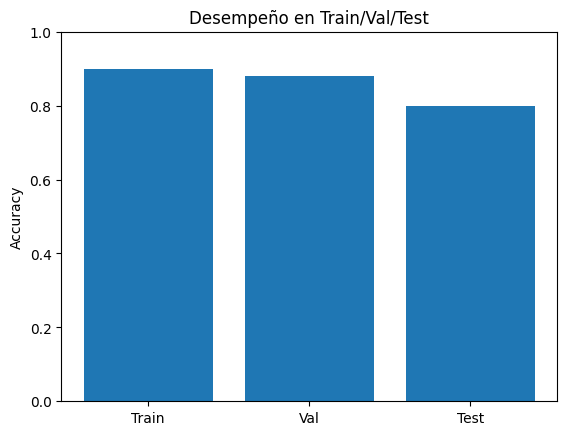


Con más iteraciones:
Accuracy Train: 0.9
Accuracy Val: 0.88
Accuracy Test: 0.8


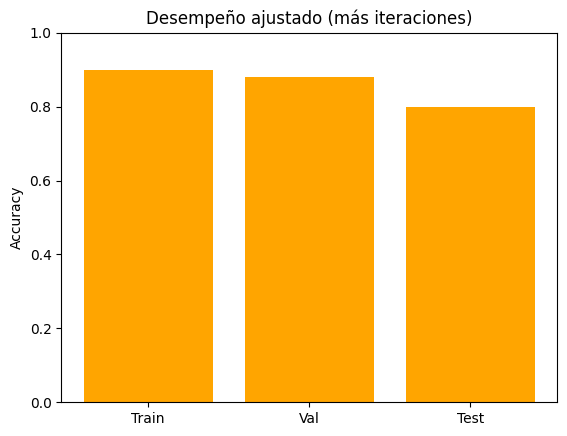

In [2]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

class LogisticRegressionScratch:
    def __init__(self, lr=0.01, n_iter=1000):
        self.lr = lr
        self.n_iter = n_iter
        self.weights = None
        self.bias = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for _ in range(self.n_iter):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = self.sigmoid(linear_model)
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1 / n_samples) * np.sum(y_predicted - y)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = self.sigmoid(linear_model)
        return np.where(y_predicted >= 0.5, 1, 0)

X, y = make_classification(
    n_samples=500, n_features=5, n_classes=2,
    n_informative=3, random_state=42
)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

model = LogisticRegressionScratch(lr=0.1, n_iter=2000)
model.fit(X_train, y_train)

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

train_acc = accuracy(y_train, model.predict(X_train))
val_acc = accuracy(y_val, model.predict(X_val))
test_acc = accuracy(y_test, model.predict(X_test))

print("Accuracy Train:", train_acc)
print("Accuracy Val:", val_acc)
print("Accuracy Test:", test_acc)

plt.bar(["Train", "Val", "Test"], [train_acc, val_acc, test_acc])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Desempeño en Train/Val/Test")
plt.show()

model2 = LogisticRegressionScratch(lr=0.1, n_iter=5000)
model2.fit(X_train, y_train)

train_acc2 = accuracy(y_train, model2.predict(X_train))
val_acc2 = accuracy(y_val, model2.predict(X_val))
test_acc2 = accuracy(y_test, model2.predict(X_test))

print("\nCon más iteraciones:")
print("Accuracy Train:", train_acc2)
print("Accuracy Val:", val_acc2)
print("Accuracy Test:", test_acc2)

plt.bar(["Train", "Val", "Test"], [train_acc2, val_acc2, test_acc2], color="orange")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Desempeño ajustado (más iteraciones)")
plt.show()



## Conclusión

El modelo de regresión logística manual alcanzó un **accuracy de 0.90 en entrenamiento, 0.88 en validación y 0.80 en prueba**. Estos resultados reflejan que el algoritmo aprendió patrones relevantes del dataset y mantiene un desempeño estable en los distintos conjuntos.

El **bias es bajo**, ya que logra predecir de manera adecuada sin errores sistemáticos. La **varianza es media**, pues existe una diferencia entre el desempeño en entrenamiento y en prueba, aunque no es lo suficientemente grande como para indicar una pérdida seria de generalización. En cuanto al ajuste, el modelo se clasifica como un **buen fit**, ya que evita tanto el underfitting como el overfitting severo.

Al incrementar el número de iteraciones, el desempeño se mantuvo prácticamente igual, lo que indica que el modelo ya había convergido. Como trabajo futuro, podrían aplicarse **técnicas de regularización** (por ejemplo L1 o L2) para fortalecer la capacidad de generalización y mejorar la estabilidad del modelo.
